# Example of Unbiased Gain


In [ ]:
import numpy as np
import pandas as pd

def gen_data(seed: int, n: int):
    """Generate synthetic data for regression (the same as the Figure 1 of the paper)"""
    rng = np.random.default_rng(seed)
    x_binary = rng.binomial(1, 0.5, size=n)
    x_discrete = rng.integers(6, size=n)
    x_continuous = rng.normal(0, 1, size=n)
    epsilon = rng.normal(0, 1, size=n)
    y = pd.Series(0.1 * x_binary + epsilon)
    X = pd.DataFrame({
        "x_1": x_binary,
        "x_2": x_discrete,
        "x_3": x_continuous,
    })
    return X, y

Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 1.01185
Early stopping, best iteration is:
[1]	valid_0's rmse: 1.00334


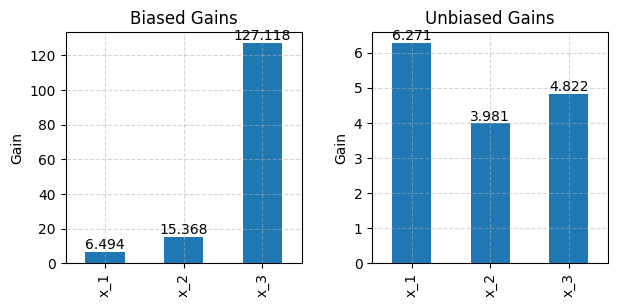

In [ ]:
import UnbiasedGain
import lightgbm as lgb
from sklearn.model_selection import train_test_split

X, y = gen_data(seed=0, n=10000)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=0)

model = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=10_000,
    min_split_gain=0.1,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100),
    ],
)

# calc -----------------------------------
losstool = UnbiasedGain.MSE_tool()
unbiased_gains = UnbiasedGain.calc_gain(model, X_train, y_train, X_val, y_val, losstool, biased=False)
unbiased_gains = dict(zip(X.columns, unbiased_gains))
gain_importance = model.booster_.feature_importance(importance_type="gain")
biased_gains = dict(zip(X.columns, gain_importance))

# plot -----------------------------------
fig, axes = plt.subplots(ncols=2, figsize=(7, 3))
for ax, gains in zip(axes, [biased_gains, unbiased_gains]):
    pd.Series(gains).round(3).plot.bar(ax=ax)
    for values in ax.containers:
        ax.bar_label(values, fontsize=10)
    ax.grid(True, ls="--", alpha=0.5)
    ax.set(
        ylabel="Gain",
        title="Biased Gains" if gains is biased_gains else "Unbiased Gains",
    )
fig.subplots_adjust(wspace=0.3)

## Monte Carlo Simulation

100%|██████████| 100/100 [19:20<00:00, 11.61s/it]


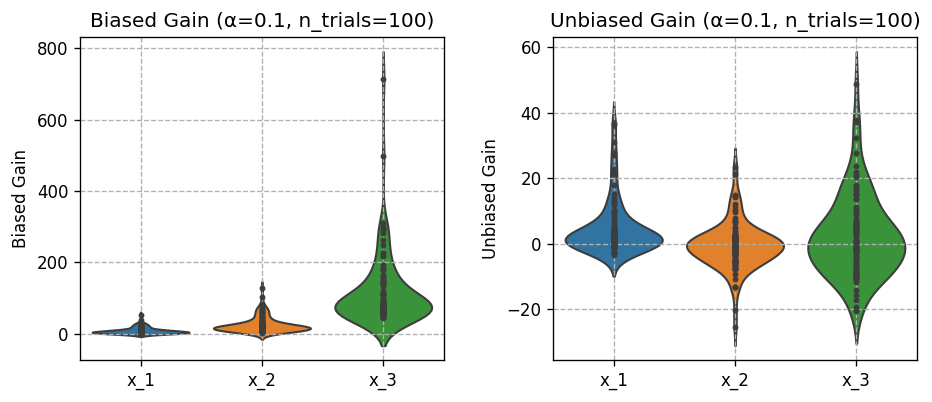

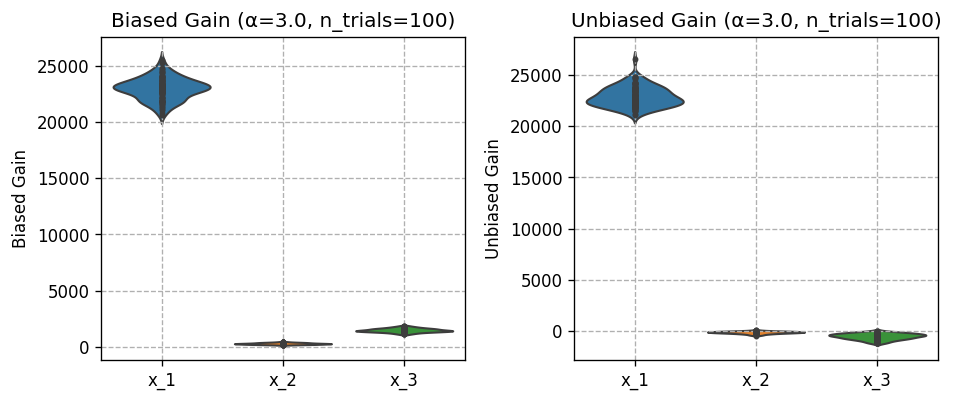

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import UnbiasedGain


def calc_importances(X: pd.DataFrame, y: pd.Series, random_state: int):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_state)

    model = lgb.LGBMRegressor(
        objective="regression",
        metric="rmse",
        n_estimators=10_000,
        min_split_gain=0.1,
        learning_rate=0.05,
        random_state=random_state,
        verbose=-1,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(stopping_rounds=10, verbose=False),
        ],
    )

    # Biased (standard) Gain
    gain_importance = model.booster_.feature_importance(importance_type="gain")
    biased_gains = dict(zip(X.columns, gain_importance))
    # Unbiased Gain
    losstool = UnbiasedGain.MSE_tool()
    unbiased_gains = UnbiasedGain.calc_gain(model, X_train, y_train, X_val, y_val, losstool, biased=False)
    unbiased_gains = dict(zip(X.columns, unbiased_gains))
    return biased_gains, unbiased_gains



def simulate(n_trials: int, n: int):
    biased_gains = []
    unbiased_gains = []

    for seed in tqdm(range(n_trials)):
        X, y = gen_data(seed=seed, n=n)
        biased_gain_imp, unbiased_gain_imp = calc_importances(X, y, random_state=seed)
        biased_gains.append(biased_gain_imp)
        unbiased_gains.append(unbiased_gain_imp)
    return pd.DataFrame(biased_gains), pd.DataFrame(unbiased_gains)


def plot_result(biased_gains: pd.DataFrame, unbiased_gains: pd.DataFrame, n_trials: int):
    fig, axes = plt.subplots(ncols=2, figsize=[9, 3.5], dpi=120)

    ax = axes[0]
    sns.violinplot(data=biased_gains, ax=ax, inner="point", fill=True)
    ax.set(ylabel="Biased Gain", title=f"Biased Gain ({n_trials=})")
    ax.grid(True, ls="--")

    ax = axes[1]
    sns.violinplot(data=unbiased_gains, ax=ax, inner="point", fill=True)
    ax.set(ylabel="Unbiased Gain", title=f"Unbiased Gain ({n_trials=})")
    ax.grid(True, ls="--")

    fig.subplots_adjust(wspace=0.3)

# # 実験 --------------------------------------------
N = 10000
N_TRIALS = 30

biased_gains, unbiased_gains = simulate(n_trials=N_TRIALS, n=N)
plot_result(biased_gains, unbiased_gains, n_trials=N_TRIALS)
